# Eksperimen SML - Muhammad Rizal Nurfirdaus
## Analisis Sentimen Review PUBG Mobile

Dataset: Review PUBG Mobile dari Google Play Store (scraping menggunakan `google_play_scraper`)

# **1. Perkenalan Dataset**

Dataset ini berisi review pengguna game PUBG Mobile dari Google Play Store.
- **Sumber**: Google Play Store (scraping)
- **Jumlah**: ~15000 review
- **Kolom**: review, rating (1-5), date, userName
- **Bahasa**: Indonesia
- **Tujuan**: Sentiment Analysis (positif/netral/negatif)

# **2. Import Library**

Mengimpor pustaka yang dibutuhkan untuk analisis data dan preprocessing.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('ggplot')
sns.set_palette('viridis')
print('Library berhasil diimport!')

Library berhasil diimport!


# **3. Memuat Dataset**

Memuat dataset CSV dari folder raw dan memeriksa struktur data.

In [2]:
df = pd.read_csv('../pubg_mobile_reviews_raw/pubg_mobile_reviews.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (15000, 4)
Columns: ['review', 'rating', 'date', 'userName']


,review,rating,date,userName
0,"game nya keren, tapi boleh hapus gak grading h...",5,2026-04-23 21:19:29,Youqo Altaaf Asari
1,perkecil lagi memori penyimpanan,5,2026-04-23 21:19:09,Bondet Junior
2,gem ini haram masa ada perempuan pakai celana ...,1,2026-04-23 20:49:28,Sri Wulan
3,Salam pelajar game ini,5,2026-04-23 20:47:50,Indra Fauzi
4,saya sangat suka,5,2026-04-23 20:35:22,maruba gultom
5,karena realita banget aku suka aku pernah ace ...,5,2026-04-23 19:58:51,arvin putra ramadan
6,yang bener aja dong pubg indo geraiding gak na...,5,2026-04-23 19:30:05,Guntur Ananta
7,👍👍👍👍👍👍,5,2026-04-23 19:25:31,beat karbu
8,jelek loginnya lama mendingan ff daripada papj...,1,2026-04-23 19:16:00,Choirus Salam
9,mantap,5,2026-04-23 18:30:03,lover Lover


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   review    15000 non-null  object
 1   rating    15000 non-null  int64 
 2   date      15000 non-null  object
 3   userName  15000 non-null  object
dtypes: int64(1), object(3)
memory usage: 468.9+ KB


In [4]:
df.describe()

,rating
count,15000.000000
mean,3.453400
std,1.773444
min,1.000000
25%,1.000000
50%,5.000000
75%,5.000000
max,5.000000


# **4. Exploratory Data Analysis (EDA)**

Melakukan EDA untuk memahami karakteristik dataset sebelum preprocessing.

In [5]:
# Cek missing values
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing Values:
review      0
rating      0
date        0
userName    0
dtype: int64

Total missing: 0


In [6]:
# Cek duplikat
dup_count = df.duplicated(subset=['review']).sum()
print(f'Jumlah review duplikat: {dup_count}')

Jumlah review duplikat: 2151


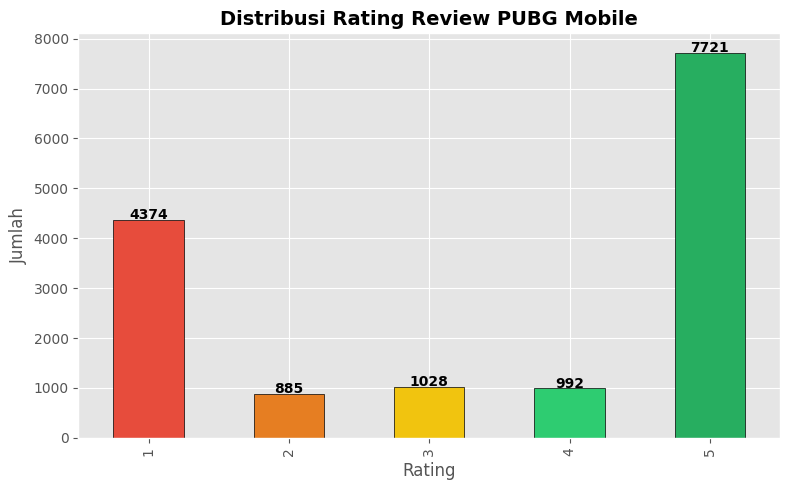

In [7]:
# Distribusi Rating
fig, ax = plt.subplots(figsize=(8, 5))
rating_counts = df['rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
rating_counts.plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Distribusi Rating Review PUBG Mobile', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Jumlah')
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

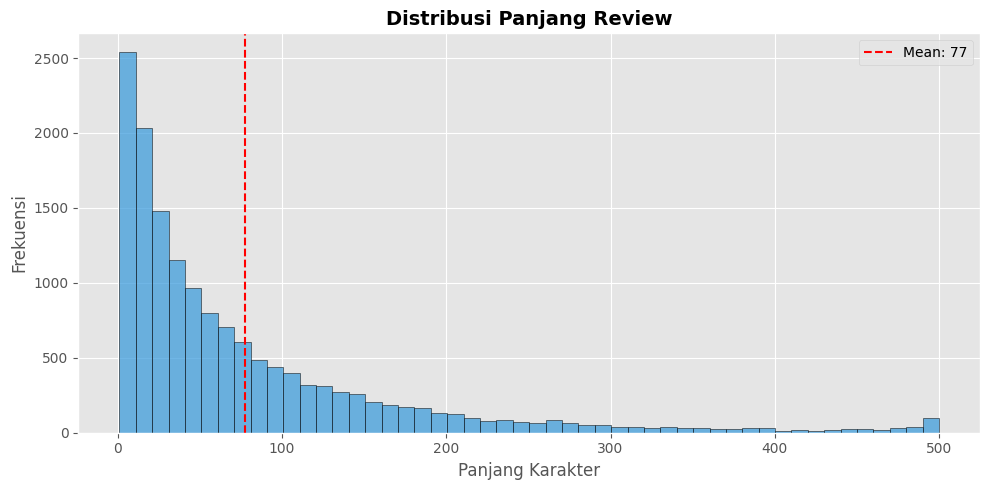

In [8]:
# Distribusi panjang review
df['review_length'] = df['review'].astype(str).apply(len)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['review_length'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax.set_title('Distribusi Panjang Review', fontsize=14, fontweight='bold')
ax.set_xlabel('Panjang Karakter')
ax.set_ylabel('Frekuensi')
ax.axvline(df['review_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['review_length'].mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

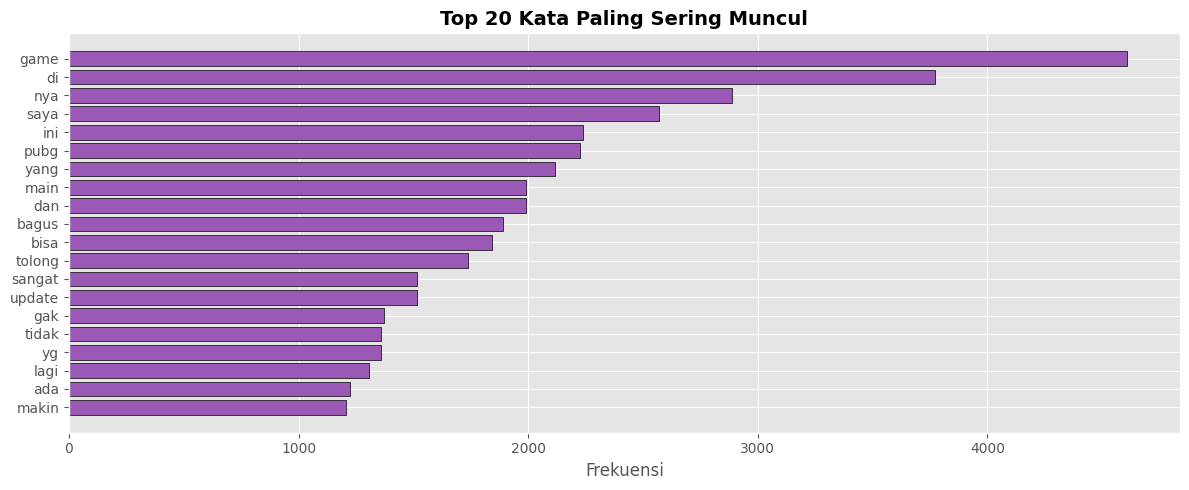

In [9]:
# Top 20 kata yang sering muncul
all_words = ' '.join(df['review'].astype(str).str.lower()).split()
word_freq = Counter(all_words).most_common(20)

fig, ax = plt.subplots(figsize=(12, 5))
words, counts = zip(*word_freq)
ax.barh(range(len(words)), counts, color='#9b59b6', edgecolor='black')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_title('Top 20 Kata Paling Sering Muncul', fontsize=14, fontweight='bold')
ax.set_xlabel('Frekuensi')
plt.tight_layout()
plt.show()

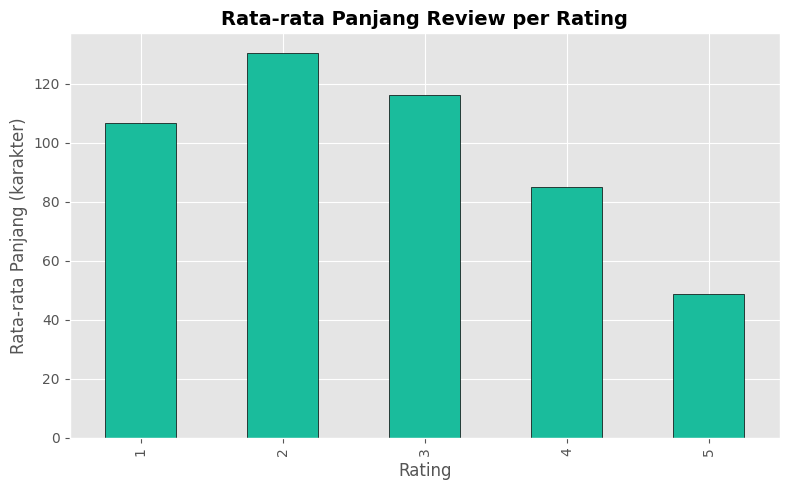

In [10]:
# Rata-rata panjang review per rating
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('rating')['review_length'].mean().plot(kind='bar', color='#1abc9c', edgecolor='black', ax=ax)
ax.set_title('Rata-rata Panjang Review per Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Rata-rata Panjang (karakter)')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Tahapan preprocessing:
1. Hapus duplikat dan missing values
2. Text cleaning (lowercase, hapus URL, emoji, special chars, angka)
3. Stopword removal (NLTK + custom Bahasa Indonesia)
4. Labeling sentimen berdasarkan rating

In [11]:
# 5.1 Hapus duplikat dan missing values
print(f'Sebelum: {len(df)} baris')
df = df.dropna(subset=['review'])
df = df.drop_duplicates(subset=['review'])
print(f'Sesudah: {len(df)} baris')

Sebelum: 15000 baris
Sesudah: 12849 baris


In [12]:
# 5.2 Text Cleaning
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)  # hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)          # hapus mention/hashtag
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)     # hapus emoji
    text = re.sub(r'\d+', '', text)                 # hapus angka
    text = re.sub(r'[^a-z\s]', '', text)            # hapus special chars
    text = re.sub(r'\s+', ' ', text).strip()        # hapus whitespace berlebih
    return text

df['review_clean'] = df['review'].apply(clean_text)
print('Contoh hasil cleaning:')
for i in range(3):
    print(f'  BEFORE: {df.iloc[i]["review"]}')
    print(f'  AFTER : {df.iloc[i]["review_clean"]}')
    print()

Contoh hasil cleaning:
  BEFORE: game nya keren, tapi boleh hapus gak grading haram itu😭
  AFTER : game nya keren tapi boleh hapus gak grading haram itu

  BEFORE: perkecil lagi memori penyimpanan
  AFTER : perkecil lagi memori penyimpanan

  BEFORE: gem ini haram masa ada perempuan pakai celana dalam aduhh mending main ff sama ml
  AFTER : gem ini haram masa ada perempuan pakai celana dalam aduhh mending main ff sama ml



In [13]:
# 5.3 Remove Stopwords
CUSTOM_STOPWORDS_ID = {
    'yang', 'di', 'dan', 'ini', 'itu', 'dengan', 'untuk', 'tidak', 'ada',
    'pada', 'ke', 'dari', 'adalah', 'juga', 'akan', 'sudah', 'bisa', 'saya',
    'aku', 'kamu', 'dia', 'kami', 'kita', 'mereka', 'nya', 'lah', 'lagi',
    'kan', 'ya', 'dong', 'sih', 'nih', 'deh', 'aja', 'gak', 'ga', 'gk',
    'nggak', 'ngga', 'udah', 'udh', 'yg', 'dg', 'dgn', 'tp', 'tapi',
    'jadi', 'jd', 'krn', 'karena', 'karna', 'dlm', 'dalam', 'sm', 'sama',
    'mau', 'mo', 'lg', 'sdh', 'blm', 'belum', 'kalau', 'kalo', 'klo',
    'bgt', 'banget', 'jgn', 'jangan', 'hrs', 'harus', 'bs', 'gw', 'gue',
    'lo', 'lu', 'emg', 'emang', 'mmg', 'memang', 'trs', 'terus',
    'dr', 'se', 'si', 'sang', 'para', 'pun', 'pula', 'lalu',
    'kemudian', 'oleh', 'dulu', 'masih', 'atau', 'serta'
}

try:
    nltk_sw = set(stopwords.words('indonesian'))
except:
    nltk_sw = set()
all_stopwords = nltk_sw | CUSTOM_STOPWORDS_ID

def remove_stopwords(text):
    if not isinstance(text, str) or text == '':
        return ''
    words = text.split()
    filtered = [w for w in words if w not in all_stopwords and len(w) > 1]
    return ' '.join(filtered)

df['review_processed'] = df['review_clean'].apply(remove_stopwords)
print('Contoh hasil remove stopwords:')
for i in range(3):
    print(f'  CLEAN    : {df.iloc[i]["review_clean"]}')
    print(f'  PROCESSED: {df.iloc[i]["review_processed"]}')
    print()

Contoh hasil remove stopwords:
  CLEAN    : game nya keren tapi boleh hapus gak grading haram itu
  PROCESSED: game keren hapus grading haram

  CLEAN    : perkecil lagi memori penyimpanan
  PROCESSED: perkecil memori penyimpanan

  CLEAN    : gem ini haram masa ada perempuan pakai celana dalam aduhh mending main ff sama ml
  PROCESSED: gem haram perempuan pakai celana aduhh mending main ff ml



In [14]:
# Hapus baris dengan review kosong setelah preprocessing
df = df[df['review_processed'].str.strip().str.len() > 0]
print(f'Baris valid setelah preprocessing: {len(df)}')

Baris valid setelah preprocessing: 12675


Distribusi Sentimen:
sentiment
positif    6581
negatif    5099
netral      995
Name: count, dtype: int64


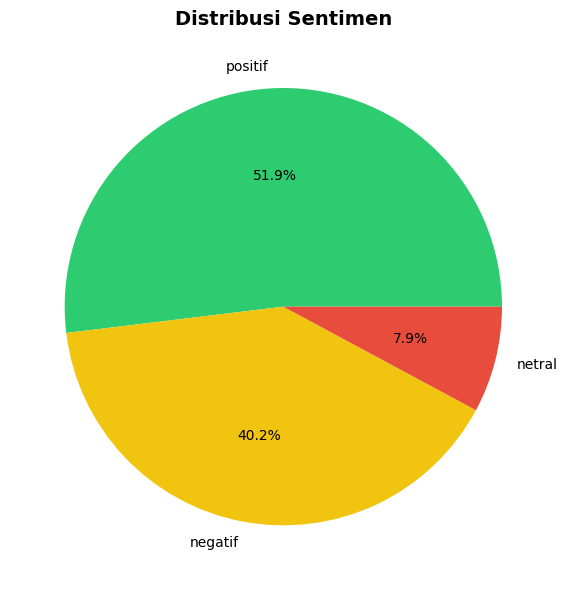

In [15]:
# 5.4 Labeling Sentimen
def label_sentiment(rating):
    if rating <= 2:
        return 'negatif'
    elif rating == 3:
        return 'netral'
    else:
        return 'positif'

df['sentiment'] = df['rating'].apply(label_sentiment)

print('Distribusi Sentimen:')
print(df['sentiment'].value_counts())

# Visualisasi
fig, ax = plt.subplots(figsize=(6, 6))
colors_pie = ['#2ecc71', '#f1c40f', '#e74c3c']
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=colors_pie, ax=ax)
ax.set_title('Distribusi Sentimen', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [16]:
# 5.5 Simpan hasil preprocessing
df_output = df[['review', 'review_clean', 'review_processed', 'rating', 'sentiment', 'date', 'userName']].copy()
df_output = df_output.reset_index(drop=True)

output_path = '../pubg_mobile_reviews_preprocessing/pubg_mobile_reviews_preprocessed.csv'
df_output.to_csv(output_path, index=False)
print(f'Data berhasil disimpan ke: {output_path}')
print(f'Shape: {df_output.shape}')
df_output.head(10)

Data berhasil disimpan ke: ../pubg_mobile_reviews_preprocessing/pubg_mobile_reviews_preprocessed.csv
Shape: (12675, 7)


,review,review_clean,review_processed,rating,sentiment,date,userName
0,"game nya keren, tapi boleh hapus gak grading h...",game nya keren tapi boleh hapus gak grading ha...,game keren hapus grading haram,5,positif,2026-04-23 21:19:29,Youqo Altaaf Asari
1,perkecil lagi memori penyimpanan,perkecil lagi memori penyimpanan,perkecil memori penyimpanan,5,positif,2026-04-23 21:19:09,Bondet Junior
2,gem ini haram masa ada perempuan pakai celana ...,gem ini haram masa ada perempuan pakai celana ...,gem haram perempuan pakai celana aduhh mending...,1,negatif,2026-04-23 20:49:28,Sri Wulan
3,Salam pelajar game ini,salam pelajar game ini,salam pelajar game,5,positif,2026-04-23 20:47:50,Indra Fauzi
4,saya sangat suka,saya sangat suka,suka,5,positif,2026-04-23 20:35:22,maruba gultom
5,karena realita banget aku suka aku pernah ace ...,karena realita banget aku suka aku pernah ace ...,realita suka ace eliminator,5,positif,2026-04-23 19:58:51,arvin putra ramadan
6,yang bener aja dong pubg indo geraiding gak na...,yang bener aja dong pubg indo geraiding gak na...,bener pubg indo geraiding bikin seters main,5,positif,2026-04-23 19:30:05,Guntur Ananta
7,jelek loginnya lama mendingan ff daripada papj...,jelek loginnya lama mendingan ff daripada papj...,jelek loginnya mendingan ff papji papjiburk bu...,1,negatif,2026-04-23 19:16:00,Choirus Salam
8,mantap,mantap,mantap,5,positif,2026-04-23 18:30:03,lover Lover
9,update terbaru. Xiaomi Pad 7 Pro di bukak 120 ...,update terbaru xiaomi pad pro di bukak fps lah...,update terbaru xiaomi pad pro bukak fps layar ...,5,positif,2026-04-23 18:24:21,Lepi Doang
